<font size=10>**GENERAL DATA PREPROCESSING**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

*«notebook description»*

<u>Text Structure</u> + <u>Vocabulary</u>

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#1)
- [2. Data](#2)
- [3. Text Structure](#3)
- [4. General Text Preprocessing](#4)
- [5. Vocabulary](#5)
- [6. Non-English Reviews - Detection and Translation](#6)
- [7. Feature Extraction](#7)
    - [7.1 TF-IDF](#7_1)
    - [7.2 Counter](#7_2)
- [8. Visualizations](#8)
    - [8.1 Categories](#8_1)
    - [8.2 Ratings](#8_2)
    

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [20]:
# pip install deep-translator
# pip install langdetect
# pip install langid
# pip install emoji

In [21]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import sys
import os
import pandas as pd
import regex as re

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from general_preprocessing import *
from visualizations import *

# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="2"></a>
  
[Back to TOC](#toc)

In [24]:
dataset_original = load_dataset('../data/atlanta_restaurant_slice_2023.csv')

In [25]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...


In [26]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [27]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Text Structure**</font> <a class="anchor" id="3"></a>
  
[Back to TOC](#toc)

In [28]:
# TODO: See how many sentences do we have in the 'review_text' column
dataset['num_sentences'] = dataset['text'].apply(lambda x: len(str(x).split('. ')))

In [29]:
dataset['num_sentences'].describe()

count    53566.000000
mean         2.783071
std          2.657222
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         43.000000
Name: num_sentences, dtype: float64

In [30]:
histogram_chart(
    data=dataset,
    column='num_sentences',
    title='Number of Sentences per Review',
    x_label='Number of Sentences'
)

# <font color='#BFD72F' size=6>**4. General Text Preprocessing**</font> <a class="anchor" id="4"></a>
  
[Back to TOC](toc)


1. **Clean Data** — Remove Extraneous Content (Part 1 & Part 2)

2. **Transform Data** — Tokenization, POS Tagging, Stopword Removal
After translation and cleaning, we tokenize the text, apply part‑of‑speech tagging, and remove stopwords (except those explicitly retained).

3. **Normalize Data** — Case, Stemming, Lemmatization
Finally, we normalize the text by lowercasing, stemming, and lemmatizing, ensuring consistent word forms for analysis.

## <font color='#BFD72F' size=6>4.1 Clean Data</font> <a class="anchor" id="4_1"></a>
  
[Back to TOC](toc)

**Remove Extraneous Content (Part 1 & Part 2)**

During preprocessing we discovered that some reviews were written in languages other than English. This posed a risk to downstream tasks such as lemmatization, tokenization, and stopword removal, since these steps rely on English linguistic rules. To ensure consistency and reliability, we decided to identify non‑English reviews and translate them into English before applying deeper transformations.

Because translation must occur at the right stage, the cleaning step was split into two parts:

- Part 1 — Pre‑Translation Cleaning
In this stage we remove elements that cannot or should not be translated, such as emojis, hashtags, newlines, and URLs.  
    - Emojis are converted into textual tokens (e.g., ❤️ → `emoji_red_heart`).  
    - Hashtags are normalized by retaining the word but removing the `@` symbol (e.g., `#great` → `great`).  
    - URLs are replaced by their main domain entity (e.g., `www.instagram.com` → `instagram`).  
    - Newlines are replaced with spaces to ensure continuity.  

After this step, the text is safe to pass through translation without losing semantic meaning or introducing noise.

- Translation
Non‑English reviews are detected using language identification tools and translated into English. This ensures that subsequent linguistic transformations are applied consistently across the dataset.

- Part 2 — Post‑Translation Cleaning
Once reviews are translated, we apply additional cleaning steps that are safe to perform on English text:  
    - Diacritics are converted to plain characters.  
    - Punctuation is removed.  
    - Repeated characters are normalized (e.g., `"soooo"` → `"soo"`).  
    - Stopwords are retained for now, but exceptions such as `again` and `not` are preserved to maintain negation and emphasis.  

This two‑step process ensures that translation happens at the right moment:  
- **Not before cleaning**, because emojis, hashtags, and URLs cannot be translated meaningfully.  
- **Not after heavy normalization**, because translation requires the original linguistic structure.  

In [31]:
# Part 1
dataset['00_before_translating_cleaning'] = dataset['text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_stopwords=False,
        stopwords_tokeep=[],
        extra_stopwords=[],
        convert_diacritics=False,
        lowercase=False,
        lemmatized=False,
        list_pos=[],
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,
        no_hashtags=True,
        hashtag_retain_words=True,
        no_newlines=True,
        no_urls=True,
        no_punctuation=False,
        treat_repeated_chars=False
    )
)

In [32]:
dataset[['text', '00_before_translating_cleaning']].iloc[[4854, 18086, 21008, 29289, 42324, 42803, 44987]]

,text,00_before_translating_cleaning
4854,❤️,emoji_red_heart
18086,✔️,emoji_check_mark
21008,⭐⭐⭐⭐⭐,emoji_staremoji_staremoji_staremoji_staremoji_...
29289,️,
42324,❤️❤️❤️❤️,emoji_red_heartemoji_red_heartemoji_red_hearte...
42803,❤️,emoji_red_heart
44987,♥️,emoji_heart_suit


In [33]:
dataset['text'].iloc[29289].strip()

'️'

In [34]:
# Detecting and Translating Non-English Reviews
dataset = process_and_translate_dataset(dataset)

In [35]:
dataset.isnull().sum()

title                                0
categoryName                         0
website                           2966
url                                  0
reviewsCount                         0
stars                                0
text                                 0
num_sentences                        0
00_before_translating_cleaning       0
lang_langdetect                      4
lang_langid                          0
needs_translation                    0
text_translated                      0
text_for_pipeline                    0
dtype: int64

In [36]:
dataset['needs_translation'].sum()

4593

In [37]:
dataset[dataset['needs_translation'] == True][['text', 'text_for_pipeline']].iloc[12].values

array(['Such an amazing dining experience.',
       'Such an amazing dining experience.'], dtype=object)

In [38]:
dataset[dataset['needs_translation'] == True][['text', 'text_for_pipeline']] \
    .reset_index()[['index', 'text', 'text_for_pipeline']] \
    .sample(1, random_state=42).values

array([[37282, 'Ml', 'Ml']], dtype=object)

In [39]:
# Part 2
dataset['01_cleaned_text'] = dataset['text_for_pipeline'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_stopwords=False,
        stopwords_tokeep=['again', 'not'],
        extra_stopwords=[],
        convert_diacritics=True,
        lowercase=False,
        lemmatized=False,
        list_pos=[],
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=False,             # already handled in Part 1
        no_hashtags=False,           # already handled in Part 1
        hashtag_retain_words=False,  # already handled in Part 1
        no_newlines=False,           # already handled in Part 1
        no_urls=False,               # already handled in Part 1
        no_punctuation=False,        # Best practice: remove punctuation after tokenization, since some marks (e.g. apostrophes in "don't") are part of valid tokens
        treat_repeated_chars=True
    )
)

## <font color='#BFD72F' size=6>4.2 Transform Data</font> <a class="anchor" id="4_2"></a>
  
[Back to TOC](toc)

**Tokenization, POS Tagging, Stopword Removal**

After translation and cleaning, we tokenize the text, apply part‑of‑speech tagging, and remove stopwords (except those explicitly retained).

*Note*: 
It is generally better to **tokenize before removing punctuation**, since punctuation marks can be part of valid tokens (e.g., `"don't"`, `"it's"`). This preserves word integrity while still removing unwanted symbols.

In [40]:
dataset['02_transformed_text'] = dataset['01_cleaned_text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_stopwords=True,
        stopwords_tokeep=['again'],
        extra_stopwords=[],
        convert_diacritics=False,
        lowercase=False,
        lemmatized=False,
        list_pos=['n', 'v', 'a', 'r', 's'],
        stemmed=False,
        pos_tags_list='pos',
        tokenized_output=True,
        no_emojis=False,
        no_hashtags=False,
        hashtag_retain_words=True,
        no_newlines=False,
        no_urls=False,
        no_punctuation=False,
        treat_repeated_chars=False
    )
)

In [41]:
# FIXME: needed? not in main_pipeline?
# POS tags for each review (aligned with 02_transformed_text tokens)
dataset["pos_tags"] = dataset["02_transformed_text"].apply(
    lambda tokens: nltk.pos_tag(tokens) if isinstance(tokens, (list, tuple)) else []
)

dataset["pos_tags"].head()

0    [(One, CD), (word, NN), (amazing, NN), (!, .),...
1    [(First, JJ), (time, NN), (food, NN), (great, ...
2    [(recently, RB), (pleasure, NN), (dining, VBG)...
3    [(Beautiful, NNP), (atmosphere, RB), (deliciou...
4    [(wonderful, JJ), (dinner, NN), (Optimist, NNP...
Name: pos_tags, dtype: object

## <font color='#BFD72F' size=6>4.3 Normalize Data</font> <a class="anchor" id="4_3"></a>
  
[Back to TOC](toc)

**Case, Stemming, Lemmatization**

Finally, we normalize the text by lowercasing, stemming, and lemmatizing, ensuring consistent word forms for analysis.

In [42]:
dataset['03_normalized_text'] = dataset['02_transformed_text'].apply(
    lambda x: main_pipeline(
        raw_text=' '.join(x) if isinstance(x, list) else x,
        no_stopwords=False,
        stopwords_tokeep=[],
        extra_stopwords=[],
        convert_diacritics=False,
        lowercase=True,
        lemmatized=True,
        list_pos=['n', 'v', 'a', 'r', 's'],
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=True,
        no_emojis=False,
        no_hashtags=False,
        hashtag_retain_words=True,
        no_newlines=False,
        no_urls=False,
        no_punctuation=True,
        treat_repeated_chars=False
    )
)

In [43]:
# Follow an example

print("Original Text Sample:\n")
print(dataset[['text']].iloc[52589].values)

print("\nTranslated Text Sample:\n")
print(dataset[['text_for_pipeline']].iloc[52589].values)

print("\nCleaned Text Sample:\n")
print(dataset[['01_cleaned_text']].iloc[52589].values)

print("\nTransformed Text Sample:\n")
print(dataset[['02_transformed_text']].iloc[52589].values)

print("\nNormalized Text Sample:\n")
print(dataset[['03_normalized_text']].iloc[52589].values)


Original Text Sample:

['Muy buena atención, la comida fresca y de buen sabor']

Translated Text Sample:

['Very good service, fresh and tasty food']

Cleaned Text Sample:

['Very good service, fresh and tasty food']

Transformed Text Sample:

[list(['good', 'service', ',', 'fresh', 'tasty', 'food'])]

Normalized Text Sample:

[list(['good', 'service', 'fresh', 'tasty', 'food'])]


In [44]:
dataset['token_count'] = dataset['02_transformed_text'].apply(len)

histogram_chart(
    data=dataset,
    column='token_count',
    title='Token Count per Review',
    x_label='Number of Tokens'
)

In [45]:
dataset['review_char_len'] = dataset['text'].astype(str).str.len()

histogram_chart(
    data=dataset,
    column='review_char_len',
    title='Review Length (Characters)',
    x_label='Number of Characters'
)

# <font color='#BFD72F' size=6>**5. Vocabulary**</font> <a class="anchor" id="5"></a>
  
[Back to TOC](#toc)

In [46]:
corpus = dataset['03_normalized_text'].explode()
print(f'Corpus Size: {len(corpus)}')
corpus

Corpus Size: 950438


0          one
0         word
0        amaze
0          red
0         fish
         ...  
53565    space
53565    table
53565     live
53565    music
53565     back
Name: 03_normalized_text, Length: 950438, dtype: object

In [47]:
vocabulary = corpus.unique()
print(f'Vocabulary Size: {len(vocabulary)}')
vocabulary

Vocabulary Size: 22252


array(['one', 'word', 'amaze', ..., 'ryleigh', 'makers', 'francaise'],
      dtype=object)

**Correcting the misspelled words**

In [48]:
vocab = list(set(word for tokens in dataset['03_normalized_text'] for word in tokens))
print("Vocabulary size:", len(vocabulary))


Vocabulary size: 22252


In [ ]:
from nltk.metrics import edit_distance
import numpy as np
from tqdm import tqdm

word_matrix = np.array([
    [edit_distance(w1, w2) for w1 in vocab]
    for w2 in tqdm(vocab)
])

# ignore identical words
word_matrix = np.where(word_matrix == 0, np.inf, word_matrix)


In [72]:
min_idx = np.where(word_matrix == word_matrix.min())
w1, w2 = vocab[min_idx[0][0]], vocab[min_idx[1][0]]
print(f"Most similar word pair: {w1} <-> {w2}")

Most similar word pair: 99 <-> 49


In [76]:
word_matrix_no_same = np.where(word_matrix == 0, np.inf, word_matrix)

In [78]:
# Flatten but keep index mapping
flat = word_matrix_no_same.flatten()

# Get indices of 10 smallest distances
top10_idx = flat.argsort()[:50]


In [79]:
top10_pairs = []
size = word_matrix_no_same.shape[0]

for idx in top10_idx:
    i = idx // size   # row index
    j = idx % size    # column index
    dist = word_matrix_no_same[i, j]
    top10_pairs.append((vocab[i], vocab[j], dist))


In [80]:
for w1, w2, d in top10_pairs:
    print(repr(w1), "<->", repr(w2), "| distance =", d)


'46' <-> '468' | distance = 1.0
'sac' <-> 'sag' | distance = 1.0
'225am' <-> '225pm' | distance = 1.0
'edit' <-> 'eait' | distance = 1.0
'wass' <-> 'waas' | distance = 1.0
'dis' <-> 'vis' | distance = 1.0
'cuz' <-> 'cut' | distance = 1.0
'slush' <-> 'shush' | distance = 1.0
'1115' <-> '1105' | distance = 1.0
'ww' <-> 'wi' | distance = 1.0
'niko' <-> 'nikko' | distance = 1.0
'54' <-> '543' | distance = 1.0
'shoo' <-> 'soo' | distance = 1.0
'thsy' <-> 'thry' | distance = 1.0
'pisces' <-> 'pieces' | distance = 1.0
'lish' <-> 'ish' | distance = 1.0
'changed' <-> 'charged' | distance = 1.0
'rat' <-> 'frat' | distance = 1.0
'mandi' <-> 'mardi' | distance = 1.0
'sa' <-> 'si' | distance = 1.0
'lp' <-> 'op' | distance = 1.0
'rad' <-> 'mad' | distance = 1.0
'seed' <-> 'see' | distance = 1.0
'glover' <-> 'lover' | distance = 1.0
'mode' <-> 'mole' | distance = 1.0
'el' <-> 'del' | distance = 1.0
'presidente' <-> 'president' | distance = 1.0
'shoo' <-> 'hoo' | distance = 1.0
'825' <-> '325' | dista

In [ ]:
for w1, w2, d in top10_pairs:
    print(f"{w1} <-> {w2}  | distance = {d}")

cite <-> gras  | distance = 1.0
cole <-> acted  | distance = 1.0
normandy <-> zensation  | distance = 1.0
exit <-> mask  | distance = 1.0
sickthe <-> comin  | distance = 1.0
456 <-> today  | distance = 1.0
takeoutthe <-> beat  | distance = 1.0
baker <-> kyra  | distance = 1.0
hao <-> crowder  | distance = 1.0
itsy <-> maika  | distance = 1.0
stepford <-> underwhelmed  | distance = 1.0
questions <-> courtney  | distance = 1.0
reina <-> 630p  | distance = 1.0
irving <-> quintessential  | distance = 1.0
spotless <-> intentioned  | distance = 1.0
amazin <-> rear  | distance = 1.0
shook <-> shimp  | distance = 1.0
prescription <-> microwaved  | distance = 1.0
swordfish <-> compendium  | distance = 1.0
northlake <-> kennedy  | distance = 1.0
cockroack <-> extrodinary  | distance = 1.0
raacal <-> 6yrsgreat  | distance = 1.0
earbuds <-> pittance  | distance = 1.0
humungous <-> byers  | distance = 1.0
guatemala <-> azul  | distance = 1.0
olego <-> spoiling  | distance = 1.0
anchor <-> msg  | di

In [84]:
# Use your existing word_matrix
threshold = 1  # distance <= threshold are considered similar

similar_groups = []

for i, w1 in enumerate(vocab):
    group = [w1]
    for j, w2 in enumerate(vocab):
        if i != j and word_matrix[i, j] <= threshold:
            group.append(w2)
    if len(group) > 1:
        similar_groups.append(list(set(group)))


In [86]:
threshold = 1  # maximum edit distance to consider words similar
printed_groups = 0
max_groups_to_print = 10  # how many example groups to show
visited = set()

for i, w1 in enumerate(vocab):
    if w1 in visited:
        continue
    group = [w1]
    for j, w2 in enumerate(vocab):
        if i != j and word_matrix[i, j] <= threshold:
            group.append(w2)
    if len(group) > 1:
        print("Similar group:", group)
        printed_groups += 1
        visited.update(group)
    if printed_groups >= max_groups_to_print:
        break


Similar group: ['99', '49', '9a', '95', '799', '699', '99c', '89', '92', '9k', '98', '9p', '959', '199', '79', '39', '90', '97', '96', '09', '929', '69', '29', '9m', '93', '9', '599', '19', '995', '59']
Similar group: ['kyler', 'tyler', 'kylee', 'kyle']
Similar group: ['coma', 'cama', 'comp', 'cola', 'come', 'roma', 'comb', 'noma', 'comma', 'toma', 'coca', 'com', 'como']
Similar group: ['bites', 'bite']
Similar group: ['gyros', 'gyro']
Similar group: ['owners', 'owner', 'ownwers']
Similar group: ['wager', 'eager', 'pager', 'waver', 'water', 'wage', 'wafer', 'lager']
Similar group: ['bluff', 'buff', 'fluff']
Similar group: ['belly', 'kelly', 'belle', 'bella', 'bally', 'billy', 'bells', 'jelly', 'bell', 'bully']
Similar group: ['momma', 'mamma', 'comma', 'mommy']


# <font color='#BFD72F' size=6>**6. Feature Extraction**</font> <a class="anchor" id="6"></a>
  
[Back to TOC](#toc)

## <font color='#BFD72F' size=6>6.1 TF-IDF</font> <a class="anchor" id="6_1"></a>
  
[Back to TOC](#toc)

In [82]:
tfidf_text, tfidf_vectorizer = vectorize_texts(dataset['03_normalized_text'])
tfidf_df = pd.DataFrame(tfidf_text.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

In [83]:
tfidf_df.sample(1, random_state=12)

,10,100,1010,12,15,18,1st,20,25,30,...,wrong,year,yes,yesterday,yet,york,young,yum,yummy,zero
11414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.160669,0.148009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
tfidf_means = tfidf_df.mean(axis=0).sort_values(ascending=False).head(20)
tfidf_top_df = pd.DataFrame({
    'token': tfidf_means.index,
    'tfidf_weight': tfidf_means.values
})
bar_chart(
    data=tfidf_top_df,
    x='token',
    y='tfidf_weight',
    title='Top 20 tokens by TF-IDF weight',
    labels={'token': 'Token', 'tfidf_weight': 'Average TF-IDF Weight'},
    top_n=20
)

{'path': '../images/visualizations/wordclouds\\tfidf_vectorization.png',
 'wordcloud': <wordcloud.wordcloud.WordCloud at 0x1afc3099480>}

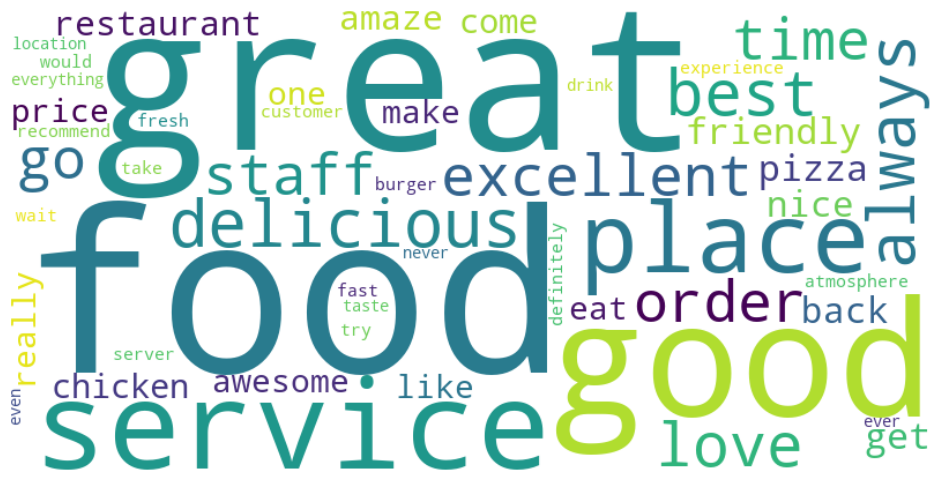

In [85]:
wordcloud_from_vectorized(
    folder_path='../images/visualizations/wordclouds',
    filename='tfidf_vectorization.png',
    vectorized_df=tfidf_df,
    top_n=50
)

In [86]:
cooc_matrix_tfidf = cooccurrence_matrix(tfidf_df, sentence_cooc=False, window_size=5)

Computing co-occurrences: 100%|██████████| 53566/53566 [00:09<00:00, 5826.46it/s]


In [87]:
display(cooc_matrix_tfidf)

,food,good,service,order,great,go,get,time,place,back,...,country,japanese,neighborhood,subway,atl,gyro,biryani,everytime,coupon,ashley
food,0,8510,9728,3335,8758,3969,3435,3704,4407,3209,...,43,74,61,25,62,57,61,50,22,34
good,8510,0,5040,2196,3277,2386,2328,2278,2810,1835,...,42,34,40,32,27,39,53,26,19,12
service,9728,5040,0,1985,6312,2288,1944,2229,2355,2028,...,32,28,33,30,37,32,28,30,25,37
order,3335,2196,1985,0,1299,2181,2406,2181,1744,1493,...,17,14,15,26,17,27,39,34,25,3
great,8758,3277,6312,1299,0,1852,1490,1882,2731,1705,...,31,26,49,19,36,38,24,36,10,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gyro,57,39,32,27,38,24,22,15,23,21,...,0,0,1,0,0,0,0,0,3,0
biryani,61,53,28,39,24,21,15,22,34,9,...,0,0,0,0,0,0,0,1,0,0
everytime,50,26,30,34,36,43,27,36,19,19,...,0,0,0,1,3,0,1,0,1,0
coupon,22,19,25,25,10,27,32,20,16,21,...,0,1,0,9,0,3,0,1,0,0


## <font color='#BFD72F' size=6>6.2 Counter</font> <a class="anchor" id="6_2"></a>
  
[Back to TOC](#toc)

In [31]:
counter_text, counter_vectorizer = vectorize_texts(
    dataset['03_normalized_text'], vectorizer_type='count'
)
counter_df = pd.DataFrame(counter_text.toarray(), columns=counter_vectorizer.get_feature_names_out())

In [32]:
counter_df.sample(1, random_state=12)

,10,100,1010,12,15,1st,20,25,30,40,...,yes,yesterday,yet,york,youll,young,youre,yum,yummy,zero
11414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
counter_means = counter_df.mean(axis=0).sort_values(ascending=False).head(20)
counter_top_df = pd.DataFrame({
    'token': counter_means.index,
    'counter_weight': counter_means.values
})
bar_chart(
    data=counter_top_df,
    x='token',
    y='counter_weight',
    title='Top 20 tokens by Counter weight',
    labels={'token': 'Token', 'counter_weight': 'Average Counter Weight'},
    top_n=20
)

{'path': '../images/visualizations/wordclouds/counter_vectorization.png',
 'wordcloud': <wordcloud.wordcloud.WordCloud at 0x1631e3890>}

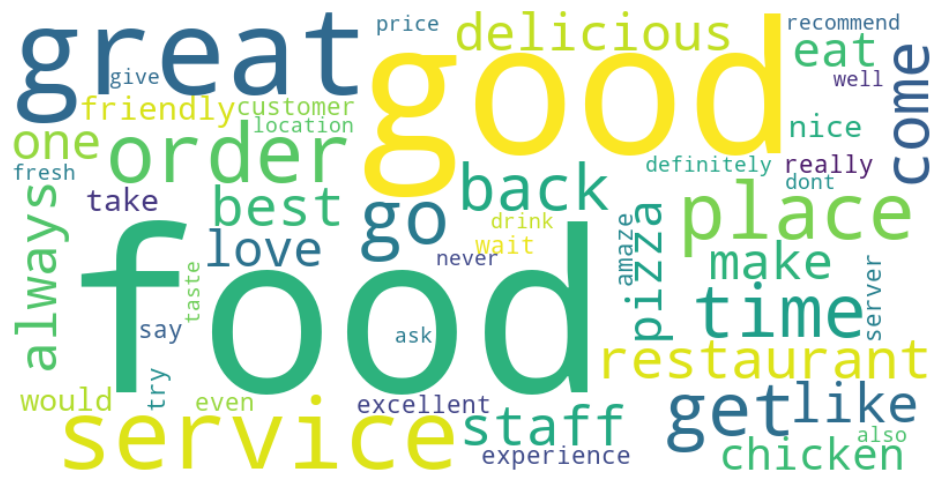

In [34]:
wordcloud_from_vectorized(
    folder_path='../images/visualizations/wordclouds',
    filename='counter_vectorization.png',
    vectorized_df=counter_df,
    top_n=50
)

# <font color='#BFD72F' size=6>**7. Visualizations**</font> <a class="anchor" id="7"></a>
  
[Back to TOC](#toc)

<font color = 'red'>**WEEK 04**

**Word Clouds** for quick visual exploration:  
- **Size →** word frequency (the bigger, the more frequent)  
- **Color →** can encode:  
  - Part of speech (noun, adjective, verb)  
  - Sentiment (e.g., red for negative, green for positive)  

**Bar Charts**  
- General keyword frequencies  
- Keywords per rating  

**Pie Charts**  
- Group by noun/adjective/verb  
- Group by rating  

**Tree Maps**  
- Group by noun/adjective/verb  
- Group by rating  

**Circle Charts**  
- Color words by sentiment intensity (color scale)  

**Network Graphs**  
- Identify clusters and relationships (color by cluster)  

**Heatmaps**  
- Correlation of features, sentiment vs. score, etc.

**Horizontal Bar Chart**
- O que o stor costuma usar para ver o tfidf nas aulas, todo colorido.


## <font color='#BFD72F' size=6>7.1 Categories</font> <a class="anchor" id="7_1"></a>
  
[Back to TOC](#toc)

In [35]:
tfidf_df = pd.DataFrame(
    tfidf_text.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df['categoryName'] = dataset['categoryName'].values

tfidf_cat_mean = tfidf_df.groupby('categoryName').mean(numeric_only=True)

no_rows = 3  # ----> Arbitrário
cats_to_plot = (
    tfidf_df['categoryName']
    .value_counts()
    .head(no_rows)
    .index
    .tolist()
)

for cat in cats_to_plot:
    top = (
        tfidf_cat_mean.loc[cat]
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
        .rename(columns={'index': 'token', cat: 'mean_tfidf'})
    )
    bar_chart(
        data=top,
        x='token',
        y='mean_tfidf',
        title=f"{cat} - Top 10 tokens by TF-IDF weight",
        labels={'token': 'Token', 'mean_tfidf': 'TF-IDF weight'},
        top_n=10
    )


## <font color='#BFD72F' size=6>7.2 Ratings</font> <a class="anchor" id="7_2"></a>
  
[Back to TOC](#toc)

In [36]:
tfidf_df = pd.DataFrame(
    tfidf_text.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df['stars'] = pd.to_numeric(dataset['stars'])

tfidf_df = tfidf_df[tfidf_df['stars'].between(1, 5, inclusive='both')].copy()

tfidf_star_mean = tfidf_df.groupby('stars').mean(numeric_only=True).sort_index()

TOP_N = 10  # ---> Arbitrário
for star in tfidf_star_mean.index:
    top = (
        tfidf_star_mean.loc[star]
        .sort_values(ascending=False)
        .head(TOP_N)
        .reset_index()
        .rename(columns={'index': 'token', star: 'mean_tfidf'})
    )
    bar_chart(
        data=top,
        x='token',
        y='mean_tfidf',
        title=f"{int(star)}★ - Top {TOP_N} tokens by TF-IDF weight",
        labels={'token': 'Token', 'mean_tfidf': 'TF-IDF weight'},
        top_n=TOP_N
    )

## <font color='#BFD72F' size=6>7.3 Word Clouds</font> <a class="anchor" id="7_3"></a>
  
[Back to TOC](#toc)

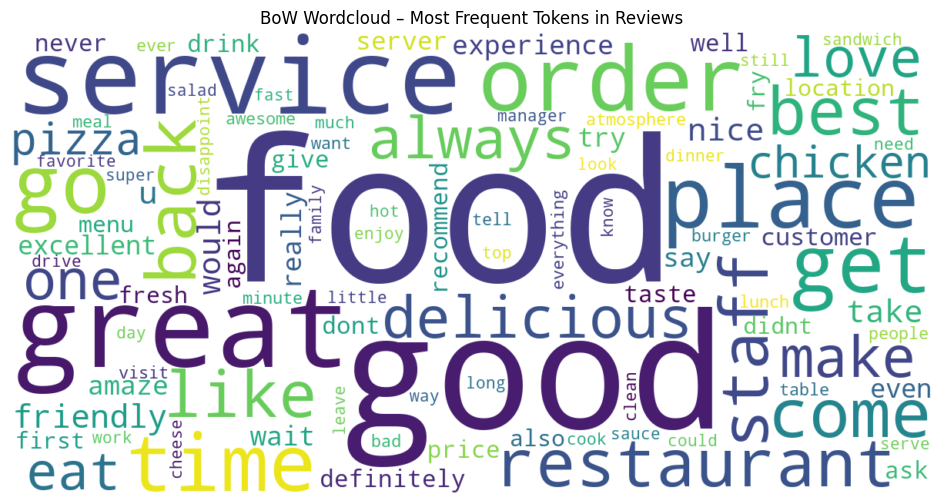

In [60]:
wordcloud_from_tokens(
    dataset["03_normalized_text"],
    max_words=100,
    title="BoW Wordcloud – Most Frequent Tokens in Reviews"
)

#### 8.3.1 Wordcloud coloured by rating


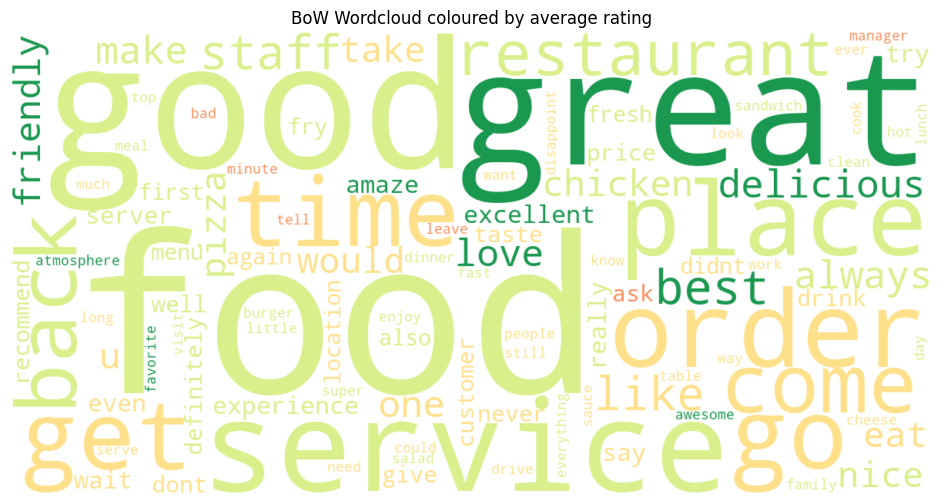

In [65]:
wordcloud_by_rating(
    token_series=dataset["03_normalized_text"],
    ratings_series=dataset["stars"],   
    max_words=100,
    title="BoW Wordcloud coloured by average rating"
)

### 8.3.2 Wordcloud coloured by Part-of-Speech (POS)



In [71]:
# Turn list of (word, tag) tuples into just a list of tags
dataset["pos_tags_simple"] = dataset["pos_tags"].apply(
    lambda sent: [tag for (_, tag) in sent] if isinstance(sent, (list, tuple)) else []
)

dataset["pos_tags_simple"].head()


0    [CD, NN, NN, JJ, NN, NN, VBD, NN, NN, NNS, VBP...
1                             [JJ, NN, NN, JJ, NN, NN]
2    [RB, NN, VBG, NNP, NNP, NNP, VB, VB, VB, JJ, N...
3    [NNP, RB, JJ, NN, NN, NN, JJ, JJ, NN, JJ, NNS,...
4          [JJ, NN, NNP, NN, CD, JJ, NN, NNS, VBP, JJ]
Name: pos_tags_simple, dtype: object

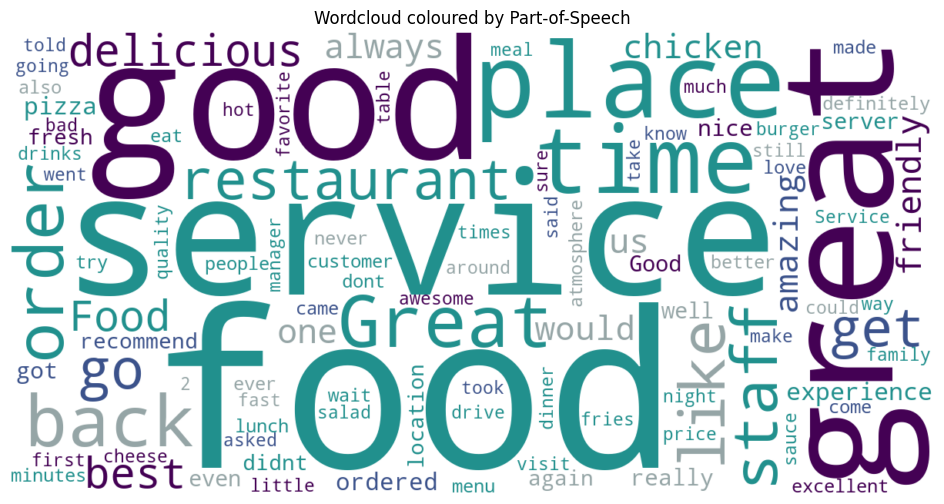

In [81]:
wc_pos = wordcloud_by_pos(
    token_series=dataset["02_transformed_text"],
    pos_series=dataset["pos_tags_simple"],   # use the simple tags
    max_words=100,
    title="Wordcloud coloured by Part-of-Speech"
)


## <font color='#BFD72F' size=6>7.4 Tree Maps</font> <a class="anchor" id="7_4"></a>
  
[Back to TOC](#toc)

In [90]:

# Convert tokens → strings
processed = dataset["03_normalized_text"].apply(
    lambda x: " ".join(x) if isinstance(x, (list, tuple)) else str(x)
)

# Reuse same CountVectorizer your function uses
vectorizer = CountVectorizer(stop_words="english")
bow_matrix = vectorizer.fit_transform(processed)

# Convert to DataFrame
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Sum frequencies
token_freq = bow_df.sum(axis=0).sort_values(ascending=False)

# Keep only TOP N
token_freq_df = (
    pd.DataFrame({
        "token": token_freq.index,
        "frequency": token_freq.values
    })
    .head(TOP_N)
    .reset_index(drop=True)
)

token_freq_df.head()

,token,frequency
0,food,28712
1,good,18016
2,great,17999
3,service,15829
4,order,10821


In [103]:
TOP_N = 100  # or whatever number you want (e.g., 50)

# token_freq_df already exists from the cell above
token_freq_df = token_freq_df.head(TOP_N)

# Treemap
treemap_chart(
    data=token_freq_df,
    path_col=["token"],       # hierarchical path — simple (1 level)
    value_col="frequency",    # size of each tile
    title=f"Treetmap of Top {TOP_N} Most Frequent Words (BoW)"
)


### 8.4.1 Tree Map by POS

In [107]:
pos_token_df = build_pos_token_freq(
    dataset["03_normalized_text"],
    dataset["pos_tags_simple"]      # use the cleaned POS tags
)

pos_token_df.head()


,pos,token,frequency
4581,NOUN,food,28698
4629,NOUN,service,15699
23473,ADJ,good,15345
23428,ADJ,great,12490
4638,NOUN,place,9278


In [108]:
TOP_N = 100
pos_token_top = pos_token_df.head(TOP_N)


In [109]:
treemap_chart(
    data=pos_token_top,
    path_col=["pos", "token"],     # hierarchy: POS → word
    value_col="frequency",
    title=f"Treemap of Top {TOP_N} Words by POS"
)


In [114]:
cooc_df = build_cooccurrence_matrix_tokens(
    dataset["03_normalized_text"],   # your token column
    top_n=200                        # use 200 for strong visualizations
)

cooc_df.head()


,food,good,great,service,order,place,go,get,time,back,...,inside,wrong,authentic,italian,keep,item,im,wont,overall,old
food,0,8243,8660,9505,3293,4311,3923,3413,3653,3177,...,464,411,597,481,512,445,421,457,547,438
good,8243,0,3250,4835,2156,2728,2346,2313,2246,1813,...,308,240,246,244,326,277,288,306,475,286
great,8660,3250,0,6247,1291,2709,1846,1483,1869,1696,...,206,139,272,274,283,199,183,181,341,209
service,9505,4835,6247,0,1948,2288,2241,1929,2192,2004,...,249,256,238,240,335,255,236,251,356,240
order,3293,2156,1291,1948,0,1727,2163,2391,2156,1484,...,305,511,98,110,290,359,282,291,266,266


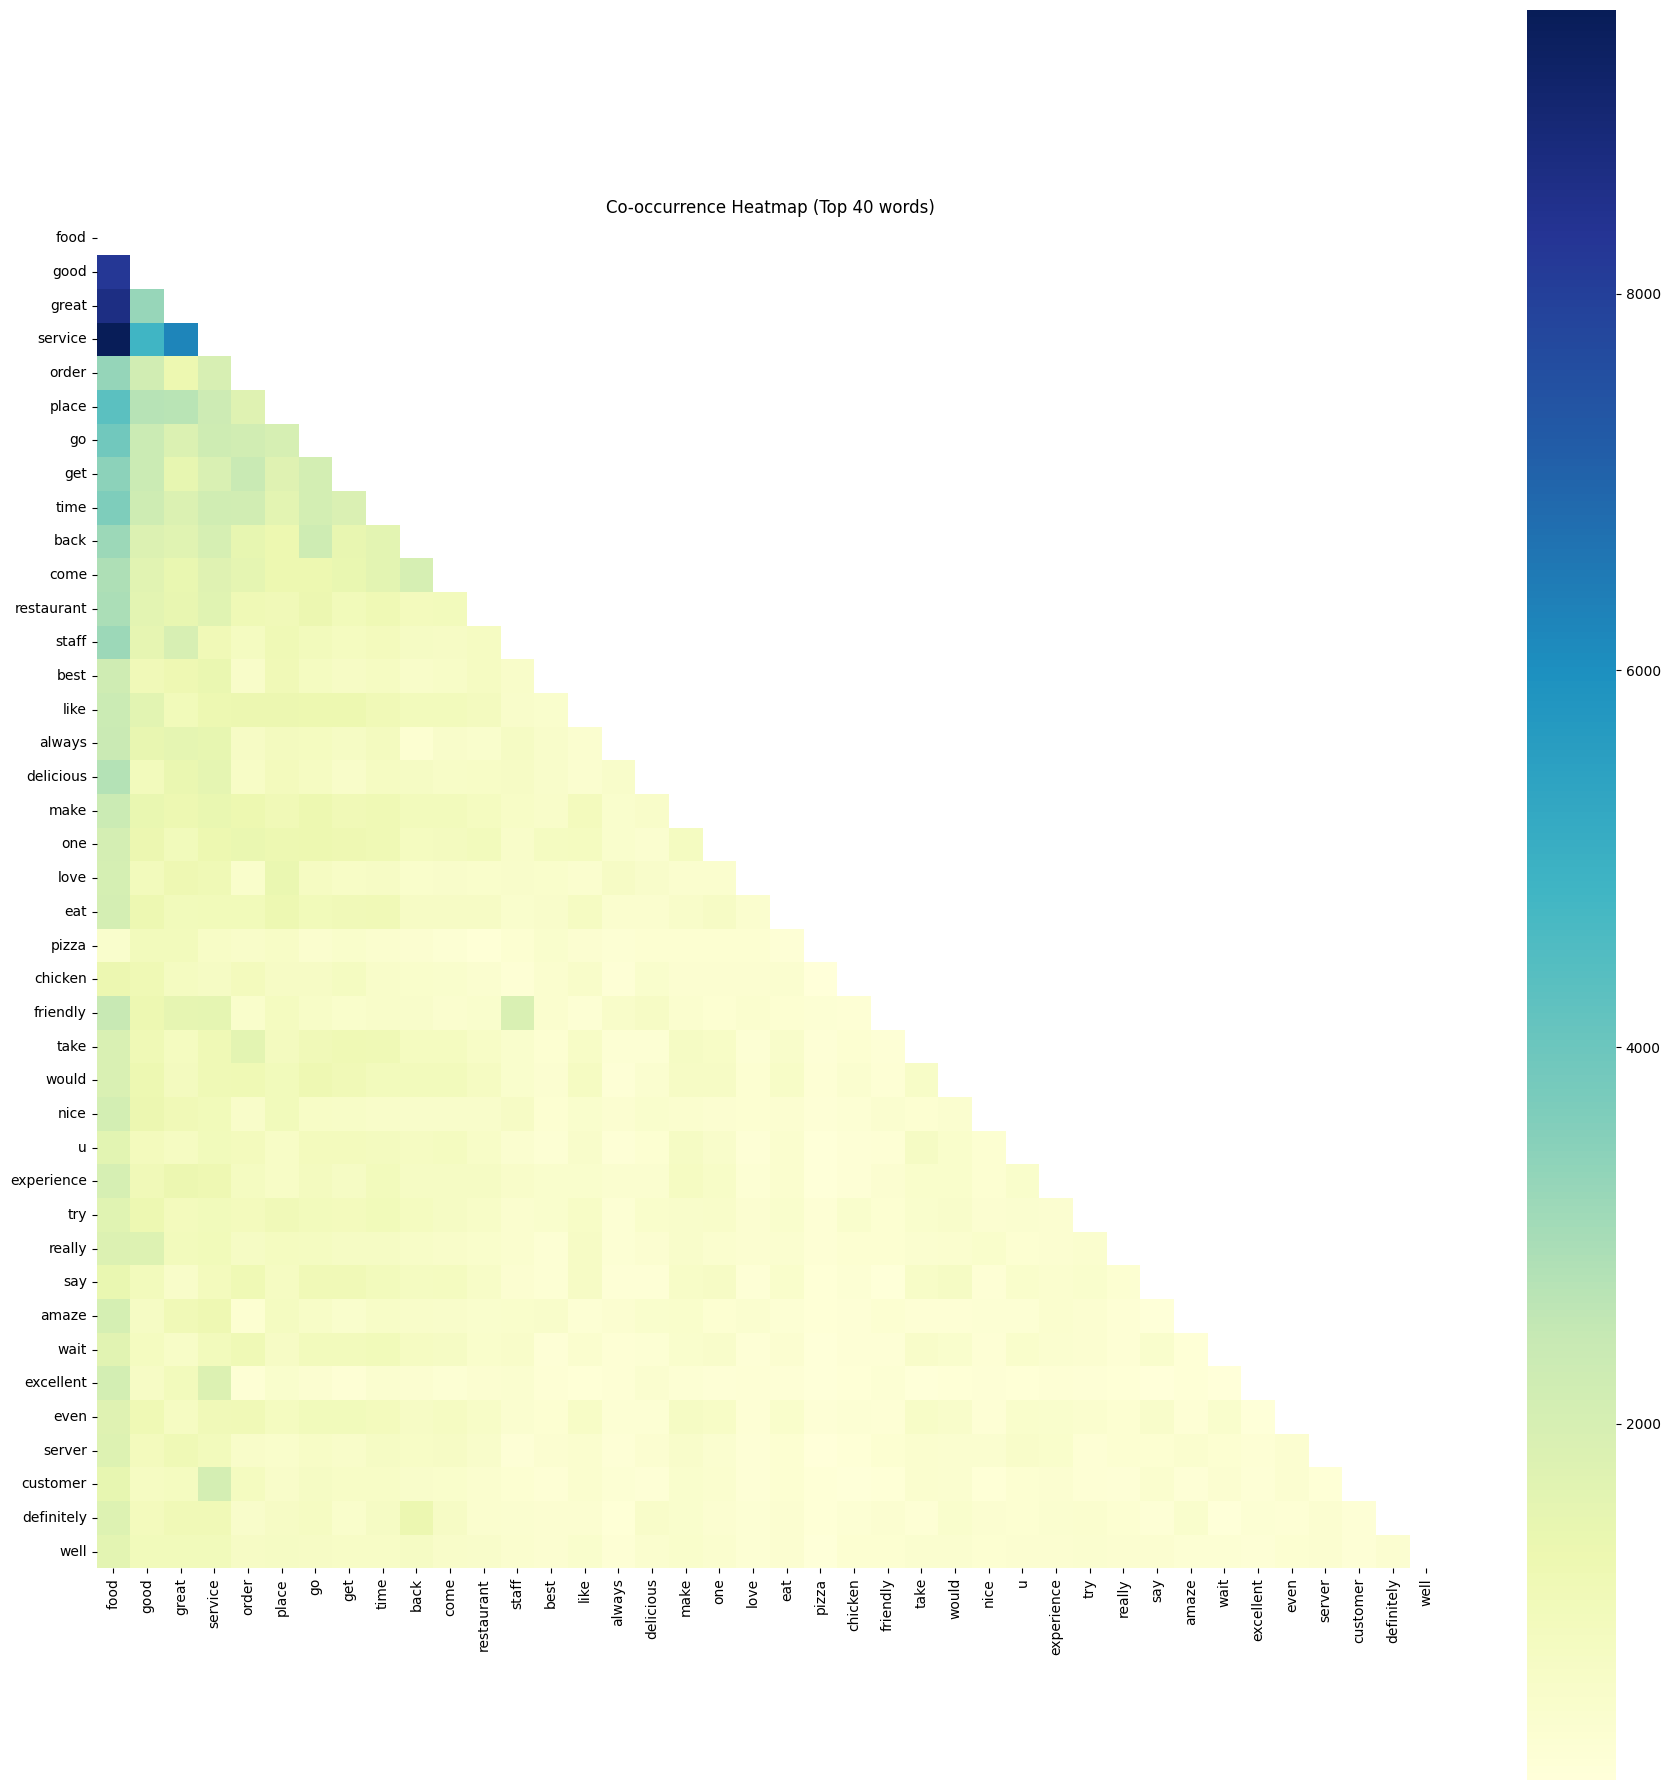

In [116]:

plot_cooccurrence_heatmap(cooc_df, top_n=40)


In [136]:
boring_words = {
    "good", "great", "place", "time", "get", "go", "make", "take", "come", "one",
    "nice", "really", "very", "always", "staff", "service", "food", "restaurant",
    "back", "order", "would", "could", "like", "best"
}

filtered_df = cooc_df.drop(index=boring_words, columns=boring_words, errors='ignore')


In [140]:
def remove_isolated_nodes(df, min_weight):
    keep = df.columns[(df > min_weight).sum(axis=1) > 0]
    return df.loc[keep, keep]

final_df = remove_isolated_nodes(filtered_df, min_weight=80)


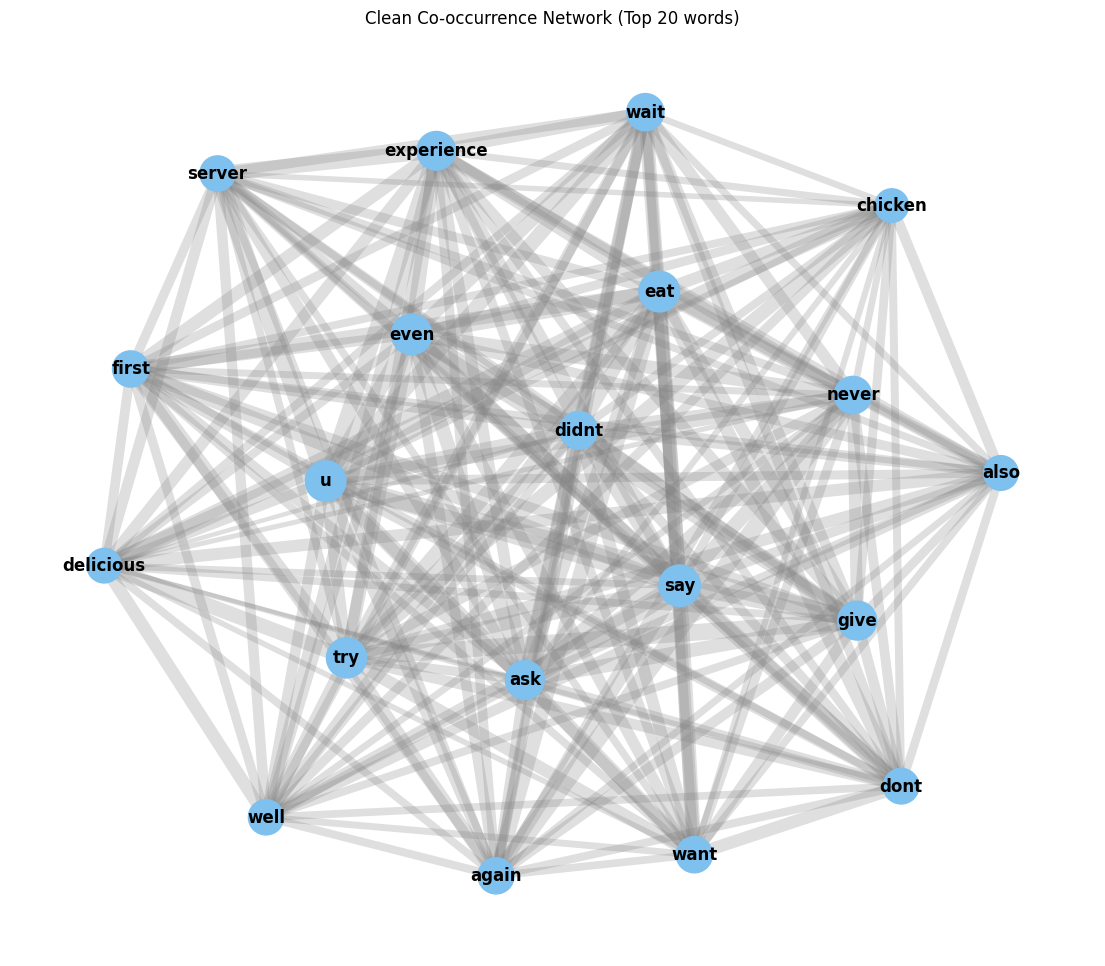

In [150]:
plot_cooccurrence_network(final_df, top_n=20, min_weight=120)
